# MaldiAMRKit - Exploratory Visualizations

This notebook demonstrates how to use MaldiAMRKit's exploratory visualization
functions to inspect MALDI-TOF datasets before building classifiers.

It covers:
- **PCA** scatter plots colored by metadata
- **t-SNE** embeddings
- **UMAP** embeddings (requires `pip install maldiamrkit[batch]`)
- Brief introduction to **batch effect correction** with `combatlearn`

In [1]:
from maldiamrkit import MaldiSet
from maldiamrkit.visualization import plot_pca, plot_tsne

## Load the Dataset

Load the example dataset bundled with MaldiAMRKit (29 spectra with
resistance labels).

In [2]:
data = MaldiSet.from_directory(
    "../data/",
    "../data/metadata/metadata.csv",
    aggregate_by=dict(antibiotics="Drug"),
    bin_width=3,
)
print(data)

MaldiSet(n_spectra=29, species='all', antibiotics=['Drug'])


In [3]:
labels = data.get_y_single("Drug")
print(f"Samples: {data.X.shape[0]}, Features: {data.X.shape[1]}")
print(f"Labels: {labels.value_counts().to_dict()}")

Samples: 29, Features: 6000
Labels: {'S': 19, 'R': 10}


## PCA

PCA is the simplest starting point. Axis labels automatically show
the explained variance percentage.

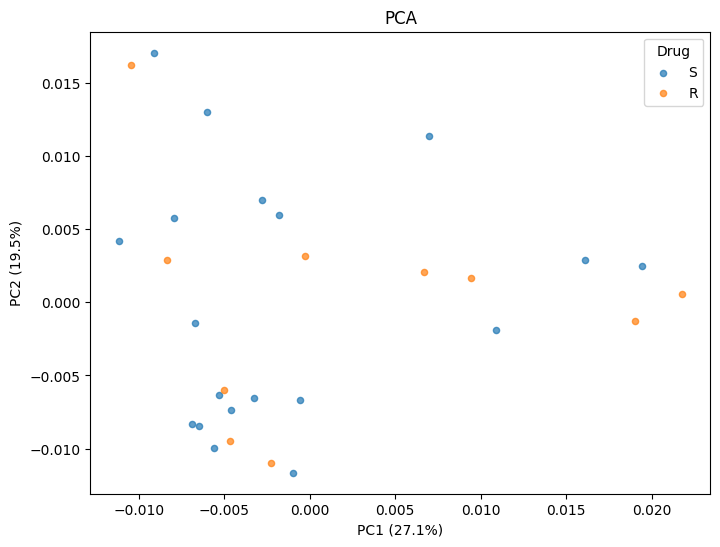

In [4]:
_ = plot_pca(data.X, color_by=labels)

You can pass any matplotlib keyword arguments through `**pca_kwargs`,
or provide a custom palette:

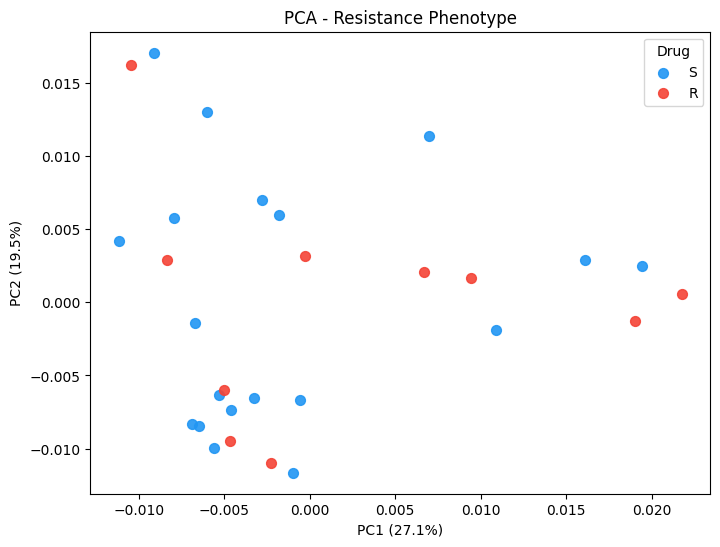

In [5]:
_ = plot_pca(
    data.X,
    color_by=labels,
    palette={"S": "#2196F3", "R": "#F44336"},
    title="PCA - Resistance Phenotype",
    alpha=0.9,
    s=50,
)

## t-SNE

For a non-linear embedding, use `plot_tsne`. With only 29 samples,
set `perplexity` low.

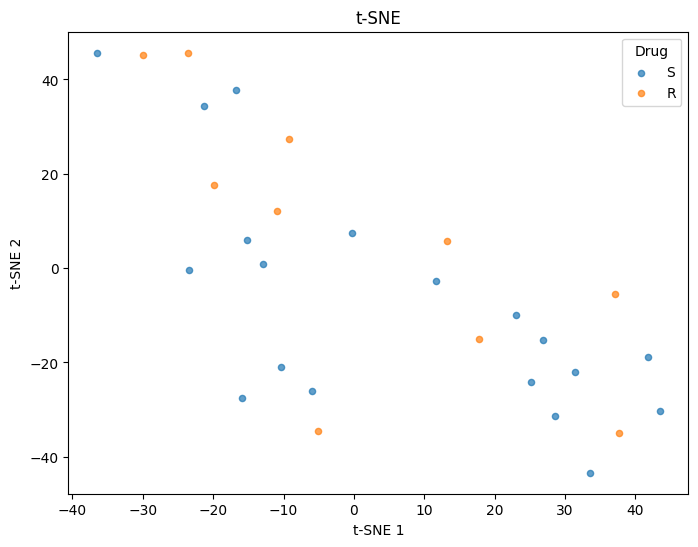

In [6]:
_ = plot_tsne(data.X, color_by=labels, perplexity=5)

## UMAP

UMAP requires the optional `umap-learn` package:

```bash
pip install maldiamrkit[batch]
```

/home/ettore/.venvs/maldiamrkit/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


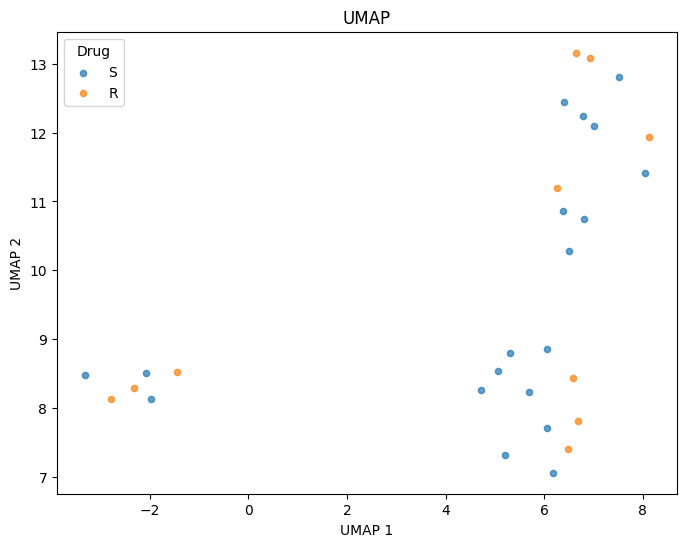

In [7]:
try:
    from maldiamrkit.visualization import plot_umap

    _ = plot_umap(data.X, color_by=labels, n_neighbors=5)
except ImportError as e:
    print(e)

## Batch Effect Correction

When combining data from multiple sites or instruments, batch effects
can dominate the signal. Use
[combatlearn](https://github.com/EttoreRocchi/combatlearn) for
ComBat-based harmonization:

```python
from combatlearn import Combat

combat = Combat(method="fortin")
combat.fit(X, y=batch_labels)
X_corrected = combat.transform(X, y=batch_labels)
```

Install with `pip install maldiamrkit[batch]`.
See the [combatlearn documentation](https://combatlearn.readthedocs.io/)
for full usage.

> Rocchi, E., Nicitra, E., Calvo, M. et al. *Combining mass spectrometry
> and machine learning models for predicting Klebsiella pneumoniae
> antimicrobial resistance: a multicenter experience from clinical
> isolates in Italy*. **BMC Microbiol** (2026).
> [doi:10.1186/s12866-025-04657-2](https://link.springer.com/article/10.1186/s12866-025-04657-2)